In [1]:
ROOT = '../..' # Relative position of the root folder.

In [2]:
import sys
sys.path.append(ROOT)

In [3]:
from libs import ConfigLoader

cfg_loader = ConfigLoader(f'{ROOT}/configs/cfg.yaml')
cfgs = cfg_loader.get_configs()
print(cfgs)

{'using_kaggle': False, 'input_folder': 'kaggle/input', 'use_dataset': 'asl-dataset', 'kaggle_override': {'input_folder': 'kaggle/input'}, 'data': {'asl-dataset': {'path': 'synthetic-asl-alphabet', 'train': 'Train_Alphabet', 'test': 'Test_Alphabet'}}, 'output': {'path': 'models/output'}}


In [4]:
from libs import ASLDataLoader

data_loader = ASLDataLoader(cfgs)
data_loader.check()

using_kaggle: False
use_dataset: asl-dataset
input_folder: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet
train_data_path: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet\Train_Alphabet
test_data_path: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet\Test_Alphabet
dataset: None
dataloader: None


In [5]:
data_loader.display_data_info(train=True)

Number of images: 24300
Number of unique classes: 27


In [6]:
data_loader.display_data_info(train=False)

Number of images: 2700
Number of unique classes: 27


In [7]:
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

In [9]:
train_dataset = data_loader.get_dataset(train=True, transform=transform)

In [10]:
import os
import random
from libs import visualize_sample_images, visualize_dataset_images, visualize_dataloader_images

Samples from Train_Alphabet


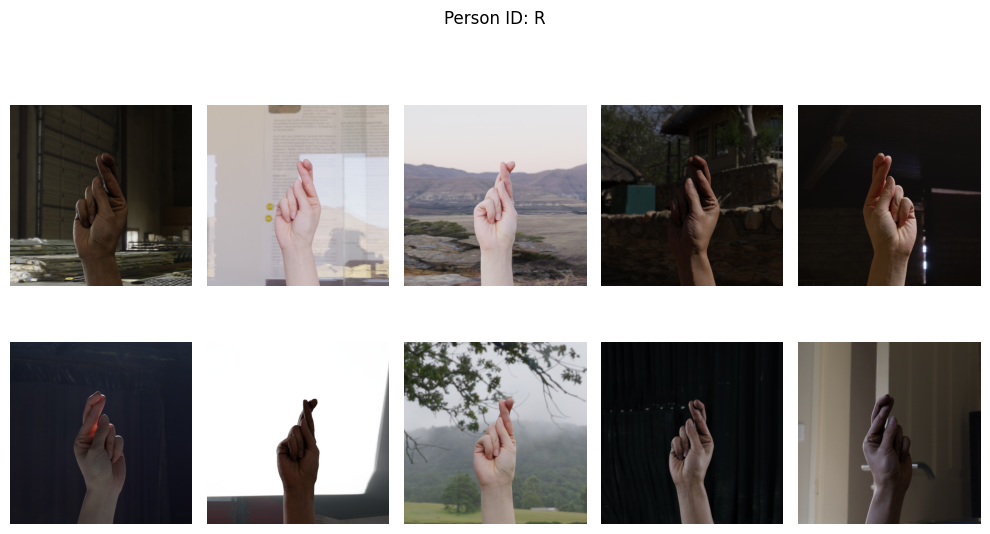

In [11]:
class_id = random.choice(os.listdir(data_loader.train_data_path))
folder_path = os.path.join(data_loader.train_data_path, class_id)
print(f'Samples from {os.path.basename(data_loader.train_data_path)}')
visualize_sample_images(folder_path)

In [12]:
train_loader = data_loader.get_dataloader(train=True, mode='standard')

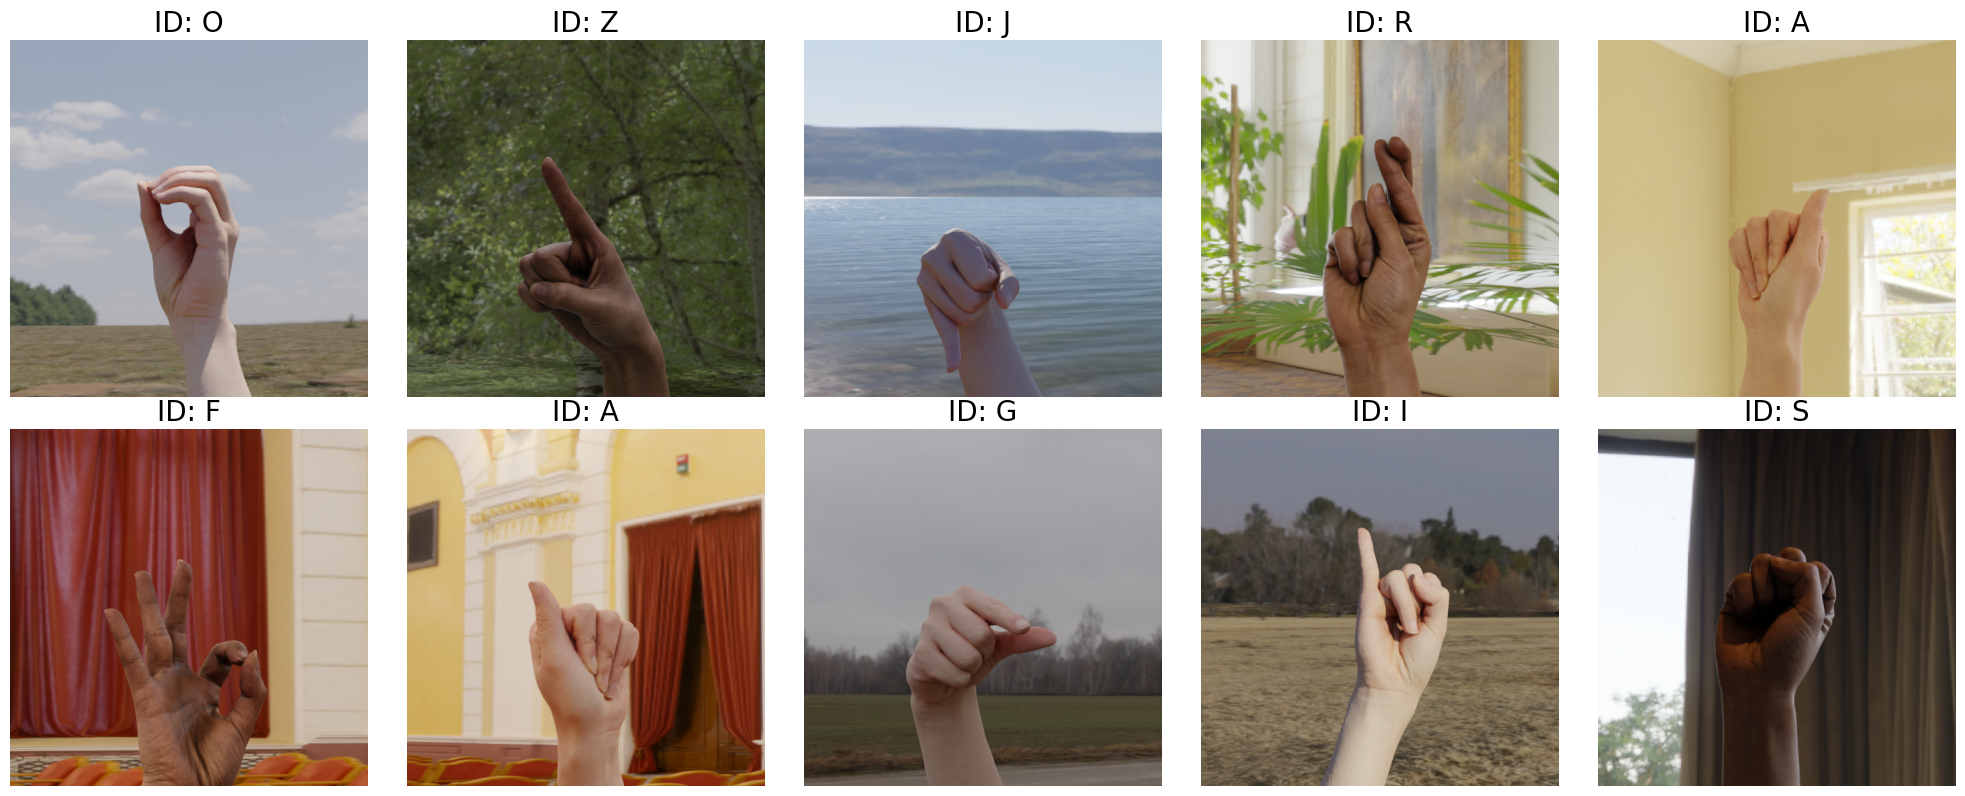

In [13]:
visualize_dataloader_images(train_loader)

In [14]:
from libs.models.efficientnet_mlp_classifier import SimpleClassifier

In [15]:
model = SimpleClassifier(num_classes=len(train_dataset.classes))

Loaded pretrained weights for efficientnet-b7
Num layers: 9


In [16]:
print(model)

SimpleClassifier(
  (model): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePa

In [17]:
from libs.trainers.trainer_ce import train_one_epoch, test_one_epoch
import torch.nn as nn
from torchvision import transforms
from torch.optim import Adam

In [18]:
test_loader = data_loader.get_dataloader(train=False, mode='standard')

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [20]:
num_epochs = 5
device = 'cuda'

In [21]:
# Move model to the specified device (GPU or CPU)
model.to(device)
train_losses, train_accus, test_losses, test_accus = [], [], [], []

for epoch in range(num_epochs):
    train_loss, train_accu = train_one_epoch(model, train_loader, criterion, optimizer, device=device, epoch=epoch)
    test_loss, test_accu = test_one_epoch(model, test_loader, criterion, device=device)

Epoch 1:   0%|          | 3/760 [00:05<24:00,  1.90s/it]


KeyboardInterrupt: 

In [ ]:
test_one_epoch(model, test_loader, criterion, device=device)

Testing: 100%|██████████| 85/85 [01:53<00:00,  1.33s/it]

Test Loss: 0.0778, Accuracy: 0.9767


In [22]:
from libs.model_loader import save_model, load_model

In [ ]:
save_model(model, f'{ROOT}/saved_models/model2.pth')

Model saved to ../../saved_models/model.pth


In [23]:
# Load the model
loaded_model = SimpleClassifier(num_classes=27)
loaded_model = load_model(loaded_model, f'{ROOT}/saved_models/model.pth')

Loaded pretrained weights for efficientnet-b7
Num layers: 9


c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\tests\3_modularization_test\../..\libs\model_loader.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_di

Model loaded from ../../saved_models/model.pth


In [24]:
loaded_model.to(device)
test_one_epoch(loaded_model, test_loader, criterion, device=device)

Testing: 100%|██████████| 85/85 [01:41<00:00,  1.19s/it]

Test Loss: 0.0778, Accuracy: 0.9767


(0.07779664459051909, tensor(0.9767, device='cuda:0', dtype=torch.float64))

In [30]:
def extract_features(model, dataloader, device='cuda'):
    model.to(device)
    model.eval()  # Set to evaluation mode
    features_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels, _ in dataloader:
            inputs = inputs.to(device)
            _, last_layer_input = model(inputs)  # Get last layer input
            features_list.append(last_layer_input.cpu().numpy())  # Store features
            labels_list.append(labels)  # Store labels

    return np.concatenate(features_list), np.concatenate(labels_list)

In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [43]:
features, labels = extract_features(loaded_model, test_loader)

In [44]:
classes = train_dataset.unique_labels

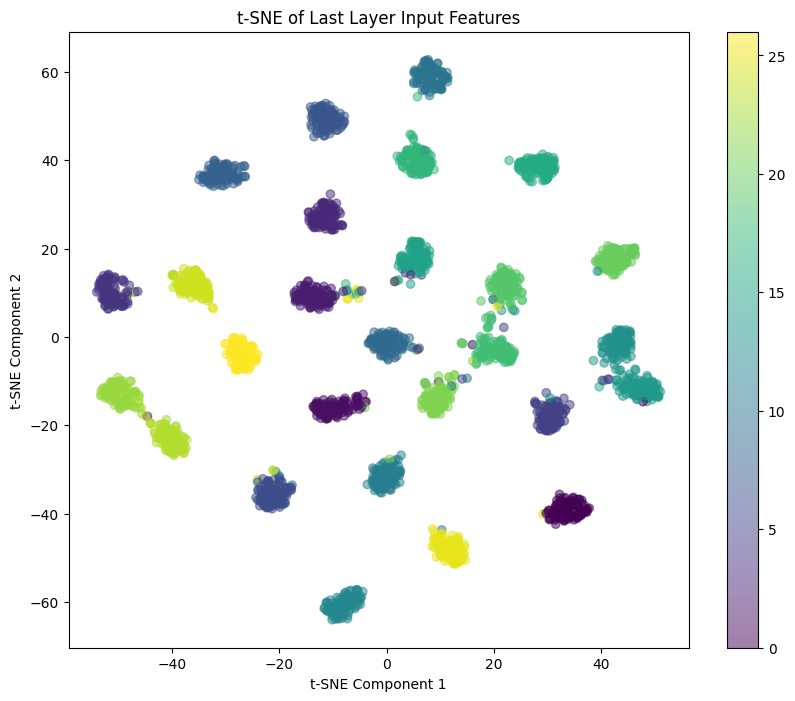

In [45]:

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

# Plotting the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=[classes[label] for label in labels], cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.title('t-SNE of Last Layer Input Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()